AI Project 2 – Traveling Salesman Problem (TSP)

We want to solve the TSP by using seven algorithms,
We have several city and distances between them so now ,not only should we find the shortest way but also the sale man has to seen each city just for once.

So we use 7 algorithms to solve this problem:
1. Backtracking
2. Forward Checking (CSP-based)
3. MVC (Minimum Remaining Values with Constraint Checking)
4. MRV (Most Restricted Variable)
5. Hill Climbing
6. Simulated Annealing
7. Genetic Algorithm (GA)
8. ** I also add Genetic Dynamic **


1. Backtracking:
In this Algorithm every possible way between city found by recursive methode, in each step we add one city to the distance until we each all cities 
We use pruning for reduse the run time,
If the partial distance of the current path exceeds the best distance found so far, we discard this path, because it can no longer lead to a better solution.
Finally, the complete route — including the return to the starting city — is calculated, and the shortest route is returned as the final solution.

2. Forward Checking (CSP-based):
So we consider each position as a variable and the possible values for each variable are the remaining cities.  Moreover if a city assigned to a position, it will removed from the options of all later positions
If any future options become empty, the branch is a dead-end, and backtracking happens early.  
so now we can say tha this approach significantly reduces the search space compared to simple backtracking.

3. MVC – Minimum Remaining Constraints (Least Constraining Value)  
this is a  method that smartly orders city selection:  
so it is remaining cities, it prefers the one that limits future choices the least   
The goal is to maintain flexibility for later decisions and avoid dead-ends as long as possible.  

4. MRV – Most Restricted Variable (Most Constrained Variable)  
Another effective CSP method:  
so at each step, it chooses the city (or position) with the fewest valid remaining options.  
This approach greatly reduces the branching factor in practice.

5. Hill Climbing  
A straightforward local search algorithm:  
we starts with a random order of cities.  
Repeatedly creates neighbors by swapping two cities.  
It is very quick but often gets stuck in local minima.

6. Simulated Annealing  
An improved version of Hill Climbing designed to escape local minima:  
Like Hill Climbing, it generates neighbors through 2-city swaps.    
A high temperature means more exploration, while a low temperature focuses on good solutions.  
This method is effective at finding nearly optimal solutions in complicated landscapes.

7. Genetic Algorithm (Standard GA)  
A population-based evolutionary method inspired by natural selection:  
Each individual represents a complete tour (a permutation of cities).  
The initial population consists of random tours.  
Fitness is calculated as 1 / total_distance (higher fitness means better tours).  
The evolution loop includes:  
  Selection  
  Ordered Crossover (OX) to maintain relative order  
  Swap mutation  
  Elitism (the best individuals automatically survive)  
This approach leads to high-quality solutions and allows for parallel processing.

8. Dynamic Genetic Algorithm (Advanced/Dynamic GA – AGA in the 2025 paper)  
An adaptable, cutting-edge enhancement of classic GA:  
Dynamic Mutation Rate: increases when improvement stalls to boost diversity and decreases when progress resumes.  
Early Stopping: halts evolution if no improvement occurs for a set number of generations.  
Diversity-Preserving Penalty: individuals that are too similar to the best receive a fitness penalty to avoid premature convergence.  
Dynamic Selection Pressure & Generation Control: adjusts tournament size and other factors during runtime.  
The outcome is greater stability, faster convergence, and better solution quality than a static GA, making it an excellent foundation for real-world DeFi fraud detection


   



In [ ]:
import random
import math
import json
import time
from typing import List, Tuple, Dict, Any


In [ ]:
def load_data(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    cities = data["cities"]
    distances = {(a, b): d for (a, b, d) in data["distances"]}
    return cities, distances

# for loading data
cities, distances = load_data("sample_input.json")

print("Cities:", cities)
print("Number of distance pairs:", len(distances))


Cities: ['A', 'B', 'C', 'D', 'E']
Number of distance pairs: 20


In [ ]:


class TSPSolver:
    """
    cities: list of city names
    distances: we use dictionary 
    """

    def __init__(self, cities: List[str], distances: Dict[Tuple[str, str], float]):
        self.cities = cities
        self.distances = distances
        self.n = len(cities)
        self.best_distance = float('inf')
        self.best_path = None

    def dist(self, a: str, b: str) -> float:
        """
        return the distance between 2 cities
        it chacke both (b,a) and (a,b)
        if there is not any adge so it should return inf
        """
        return (
            self.distances.get((a, b))
            or self.distances.get((b, a))
            or float('inf')
        )

    def total_distance(self, path: List[str]) -> float:
        """
        calulating the distance by including return to the first city
        """
        total = 0.0
        for i in range(len(path) - 1):
            total += self.dist(path[i], path[i + 1])
        total += self.dist(path[-1], path[0])  #back to the first city 
        return total

    # -------------------------------------------------------------------------
    # 1. Backtracking
    # -------------------------------------------------------------------------
    def solve_backtracking(self) -> Tuple[List[str], float]:
        
        self.best_distance = float('inf')
        self.best_path = None

        start = self.cities[0]

        def backtrack(path: List[str], visited: set, current_dist: float):
            # if we seen all cities
            if len(path) == self.n:
                
                total = current_dist + self.dist(path[-1], start)
                if total < self.best_distance:
                    self.best_distance = total
                    self.best_path = path + [start]
                return

            last_city = path[-1]

            
            for city in self.cities:
                if city in visited:
                    continue

                edge = self.dist(last_city, city)

                # if there is not any edge
                if edge == float('inf'):
                    continue

                #we use pruning , like if now already we are worst than the best position or solution , so we give up
                if current_dist + edge >= self.best_distance:
                    continue

                backtrack(
                    path + [city],
                    visited | {city},
                    current_dist + edge
                )

        # start from the first city
        backtrack([start], {start}, 0.0)

        return self.best_path or [], self.best_distance
    # -------------------------------------------------------------------------
    # 2. Forward Checking (CSP-based)
    # -------------------------------------------------------------------------
    def solve_forward_checking(self) -> Tuple[List[str], float]:
        
        self.best_distance = float('inf')
        self.best_path = None

        start = self.cities[0]

        path = [None] * self.n
        path[0] = start
        #the domain of each position
        domains: List[set] = [set(self.cities) for _ in range(self.n)]
        domains[0] = {start}  
        for p in range(1, self.n):
            domains[p].discard(start)

        def forward_remove(city: str, pos: int) -> List[Tuple[int, str]]:
            removed = []
            for p in range(pos + 1, self.n):
                if city in domains[p]:
                    domains[p].remove(city)
                    removed.append((p, city))
            return removed

        def undo_forward(removed: List[Tuple[int, str]]):
            for p, city in removed:
                domains[p].add(city)

        def search(pos: int, current_dist: float):
            if pos == self.n:
                total = current_dist + self.dist(path[-1], start)
                if total < self.best_distance:
                    self.best_distance = total
                    self.best_path = path[:] + [start]
                return

            for p in range(pos, self.n):
                if not domains[p]:
                    return

            prev_city = path[pos - 1]

            for city in list(domains[pos]):
                edge = self.dist(prev_city, city)
                if edge == float('inf'):
                    continue

                new_dist = current_dist + edge
                if new_dist >= self.best_distance:
                    continue

                path[pos] = city

                removed = forward_remove(city, pos)

                search(pos + 1, new_dist)

                undo_forward(removed)
                path[pos] = None

        search(1, 0.0)
        return self.best_path or [], self.best_distance
    # -------------------------------------------------------------------------
    # 3. MVC (Minimum Remaining Constraints heuristic)
    # -------------------------------------------------------------------------
    def solve_mvc(self) -> Tuple[List[str], float]:
       
        self.best_distance = float('inf')
        self.best_path = None

        start = self.cities[0]
        path: List[str] = [start]
        used = {start}

        def backtrack(pos: int, current_dist: float):
            #if already we has selected all city or seen them before
            if pos == self.n:
                return_dist = self.dist(path[-1], start)
                total = current_dist + return_dist
                if total < self.best_distance:
                    self.best_distance = total
                    self.best_path = path[:] + [start]
                return

            
            candidates = [c for c in self.cities if c not in used]
            if not candidates:
                return

            prev_city = path[-1]

            
            def remaining_constraints(city: str) -> int:
                
                remaining = [x for x in self.cities if x not in used and x != city]
                count = 0
                for other in remaining:
                    if self.dist(city, other) < float('inf'):
                        count += 1
                return count  

            candidates.sort(key=remaining_constraints)

            for city in candidates:
                edge = self.dist(prev_city, city)
                if edge == float('inf'):
                    continue  

                new_dist = current_dist + edge
                if new_dist >= self.best_distance:
                    continue  # pruning

                path.append(city)
                used.add(city)

                backtrack(pos + 1, new_dist)

                used.remove(city)
                path.pop()

        backtrack(1, 0.0)
        return self.best_path or [], self.best_distance
    # -------------------------------------------------------------------------
    # 4. MRV (Most Restricted Variable)
    # -------------------------------------------------------------------------
    def solve_mrv(self) -> Tuple[List[str], float]:
        
        self.best_distance = float('inf')
        self.best_path = None

        start = self.cities[0]
        path: List[str] = [start]
        used = {start}

        def get_available_cities() -> List[str]:
            return [c for c in self.cities if c not in used]

        def backtrack(pos: int, current_dist: float):
            #if all city has selected or choosed
            if pos == self.n:
                return_dist = self.dist(path[-1], start)
                total = current_dist + return_dist
                if total < self.best_distance:
                    self.best_distance = total
                    self.best_path = path[:] + [start]
                return

            candidates = get_available_cities()
            if not candidates:
                return

            prev_city = path[-1]

            def restriction_level(city: str) -> int:
                
                remaining = [c for c in self.cities if c not in used and c != city]
                count = 0
                for other in remaining:
                    if self.dist(city, other) < float('inf'):
                        count += 1
                return count  

            candidates.sort(key=restriction_level)

            for city in candidates:
                edge = self.dist(prev_city, city)
                if edge == float('inf'):
                    continue  

                new_dist = current_dist + edge
                if new_dist >= self.best_distance:
                    continue  # pruning

                path.append(city)
                used.add(city)

                backtrack(pos + 1, new_dist)

                used.remove(city)
                path.pop()

        backtrack(1, 0.0)
        return self.best_path or [], self.best_distance
    # -------------------------------------------------------------------------
    # 5. Hill Climbing
    # -------------------------------------------------------------------------
    def solve_hill_climbing(self, max_iterations: int = 1000) -> Tuple[List[str], float]:
       
        current_path = self.cities[:]
        random.shuffle(current_path)
        current_distance = self.total_distance(current_path)

        best_path = current_path[:]
        best_distance = current_distance

        for _ in range(max_iterations):
            i, j = random.sample(range(self.n), 2)
            neighbor_path = current_path[:]
            neighbor_path[i], neighbor_path[j] = neighbor_path[j], neighbor_path[i]
            neighbor_distance = self.total_distance(neighbor_path)

            if neighbor_distance < current_distance:
                current_path = neighbor_path
                current_distance = neighbor_distance

                if current_distance < best_distance:
                    best_distance = current_distance
                    best_path = current_path[:]

        self.best_path = best_path + [best_path[0]]  
        self.best_distance = best_distance

        return self.best_path, self.best_distance
    # -------------------------------------------------------------------------
    # 6. Simulated Annealing
    # -------------------------------------------------------------------------
    def solve_simulated_annealing(
        self,
        temp: float = 10_000.0,
        cooling: float = 0.9995,
        stop_temp: float = 1e-8
    ) -> Tuple[List[str], float]:
       

        current = self.cities[:]
        random.shuffle(current)
        current_dist = self.total_distance(current)

        best = current[:]
        best_dist = current_dist

        while temp > stop_temp:
            i, j = random.sample(range(self.n), 2)
            neighbor = current[:]
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            neighbor_dist = self.total_distance(neighbor)

            delta = neighbor_dist - current_dist

            if delta < 0 or random.random() < math.exp(-delta / temp):
                current = neighbor
                current_dist = neighbor_dist

                if current_dist < best_dist:
                    best = current[:]
                    best_dist = current_dist

            temp *= cooling

        self.best_path = best + [best[0]]  
        self.best_distance = best_dist

        return self.best_path, self.best_distance
    # -------------------------------------------------------------------------
    # 7. Genetic Algorithm
    # -------------------------------------------------------------------------
    def solve_genetic(
        self,
        population_size: int = 80,
        generations: int = 300,
        mutation_rate: float = 0.05,
        elite_size: int = 2,
        tournament_size: int = 5
    ) -> Tuple[List[str], float]:
        


        def create_individual() -> List[str]:
            indiv = self.cities[:]
            random.shuffle(indiv)
            return indiv

        def fitness(path: List[str]) -> float:
            dist = self.total_distance(path)
            if dist == 0:
                return float("inf")
            return 1.0 / dist

        def tournament_selection(population: List[List[str]]) -> List[str]:
            competitors = random.sample(population, min(tournament_size, len(population)))
            best = max(competitors, key=fitness)
            return best

        def ordered_crossover(parent1: List[str], parent2: List[str]) -> List[str]:
            
            size = self.n
            child = [None] * size

            i, j = sorted(random.sample(range(size), 2))
            child[i:j+1] = parent1[i:j+1]

            p2_idx = 0
            for k in range(size):
                if child[k] is None:
                    while parent2[p2_idx] in child:
                        p2_idx += 1
                    child[k] = parent2[p2_idx]

            return child

        def mutate(path: List[str]) -> None:
            if random.random() < mutation_rate:
                i, j = random.sample(range(self.n), 2)
                path[i], path[j] = path[j], path[i]

        population: List[List[str]] = [create_individual() for _ in range(population_size)]

        best_individual = min(population, key=lambda p: self.total_distance(p))
        best_distance = self.total_distance(best_individual)

        for _ in range(generations):
            population.sort(key=lambda p: self.total_distance(p))
            new_population: List[List[str]] = []

            elites = population[:elite_size]
            new_population.extend(elites)

            while len(new_population) < population_size:
                parent1 = tournament_selection(population)
                parent2 = tournament_selection(population)

                child = ordered_crossover(parent1, parent2)
                mutate(child)
                new_population.append(child)

            population = new_population

            current_best = min(population, key=lambda p: self.total_distance(p))
            current_best_dist = self.total_distance(current_best)
            if current_best_dist < best_distance:
                best_distance = current_best_dist
                best_individual = current_best[:]

        self.best_path = best_individual + [best_individual[0]]
        self.best_distance = best_distance

        return self.best_path, self.best_distance
    # -------------------------------------------------------------------------
    # 7b. Dynamic Genetic Algorithm
    # -------------------------------------------------------------------------
    def solve_genetic_dynamic(
        self,
        population_size: int = 80,
        max_generations: int = 600,
        base_mutation_rate: float = 0.05,
        elite_size: int = 2,
        base_tournament_size: int = 4,
        min_mutation: float = 0.01,
        max_mutation: float = 0.3,
        patience_mutation: int = 10,   # هر چند نسل بدون بهبود → mutation را تنظیم کن
        patience_stop: int = 40,       # اگر این تعداد نسل بهبود نداشتیم → stop
        similarity_penalty: float = 0.3  # شدت جریمه برای شباهت زیاد به بهترین فرد
    ) -> Tuple[List[str], float]:


        def create_individual() -> List[str]:
            #creat a coromozom:) random way
            
            indiv = self.cities[:]
            random.shuffle(indiv)
            return indiv

        def path_distance(path: List[str]) -> float:
            return self.total_distance(path)

        def similarity(path: List[str], best: List[str]) -> float:
            
            same = sum(1 for a, b in zip(path, best) if a == b)
            return same / len(path)

        def fitness(path: List[str], current_best: List[str]) -> float:
            
            dist = path_distance(path)
            if dist == 0:
                return float("inf")

            sim = similarity(path, current_best)
            effective_dist = dist * (1.0 + similarity_penalty * sim)
            return 1.0 / effective_dist

        def tournament_selection(population: List[List[str]], current_best: List[str], tournament_size: int) -> List[str]:
            competitors = random.sample(population, min(tournament_size, len(population)))
            best = max(competitors, key=lambda p: fitness(p, current_best))
            return best

        def ordered_crossover(parent1: List[str], parent2: List[str]) -> List[str]:
            
            size = self.n
            child = [None] * size

            i, j = sorted(random.sample(range(size), 2))
            child[i:j+1] = parent1[i:j+1]

            p2_idx = 0
            for k in range(size):
                if child[k] is None:
                    while parent2[p2_idx] in child:
                        p2_idx += 1
                    child[k] = parent2[p2_idx]

            return child

        def mutate(path: List[str], mutation_rate: float) -> None:
            """swap mutation با احتمال mutation_rate."""
            if random.random() < mutation_rate:
                i, j = random.sample(range(self.n), 2)
                path[i], path[j] = path[j], path[i]

        population: List[List[str]] = [create_individual() for _ in range(population_size)]

        best_individual = min(population, key=path_distance)
        best_distance = path_distance(best_individual)

        mutation_rate = base_mutation_rate
        no_improve_count = 0

        for gen in range(max_generations):
            tournament_size = min(base_tournament_size + gen // 150, population_size)

            population.sort(key=path_distance)
            new_population: List[List[str]] = []

            elites = population[:elite_size]
            new_population.extend(elites)

            while len(new_population) < population_size:
                parent1 = tournament_selection(population, best_individual, tournament_size)
                parent2 = tournament_selection(population, best_individual, tournament_size)

                child = ordered_crossover(parent1, parent2)
                mutate(child, mutation_rate)
                new_population.append(child)

            population = new_population

            current_best = min(population, key=path_distance)
            current_best_dist = path_distance(current_best)

            if current_best_dist + 1e-9 < best_distance:
                improvement = best_distance - current_best_dist
                best_distance = current_best_dist
                best_individual = current_best[:]
                no_improve_count = 0

                mutation_rate = max(min_mutation, mutation_rate * 0.9)
            else:
                no_improve_count += 1

                if no_improve_count % patience_mutation == 0:
                    mutation_rate = min(max_mutation, mutation_rate * 1.2)

                if no_improve_count >= patience_stop:
                    break

        self.best_path = best_individual + [best_individual[0]]
        self.best_distance = best_distance

        return self.best_path, self.best_distance







        


In [ ]:
import time

def run_exact_algorithm(name, solve_method):
    
    solver = TSPSolver(cities, distances)
    start = time.time()
    path, dist_val = solve_method(solver)
    end = time.time()
    return {
        "name": name,
        "distance": dist_val,
        "time": end - start
    }

def run_stochastic_algorithm(name, solve_method, runs=5):
   
    best_distance = float('inf')
    best_time = None

    for _ in range(runs):
        solver = TSPSolver(cities, distances)
        start = time.time()
        path, dist_val = solve_method(solver)
        end = time.time()

        if dist_val < best_distance:
            best_distance = dist_val
            best_time = end - start

    return {
        "name": name,
        "distance": best_distance,
        "time": best_time
    }

results = []

results.append(run_exact_algorithm("Backtracking", lambda s: s.solve_backtracking()))
results.append(run_exact_algorithm("Forward Checking", lambda s: s.solve_forward_checking()))
results.append(run_exact_algorithm("MVC", lambda s: s.solve_mvc()))
results.append(run_exact_algorithm("MRV", lambda s: s.solve_mrv()))

results.append(run_stochastic_algorithm("Hill Climbing", lambda s: s.solve_hill_climbing(max_iterations=1000), runs=5))
results.append(run_stochastic_algorithm("Simulated Annealing", lambda s: s.solve_simulated_annealing(), runs=5))
results.append(run_stochastic_algorithm("Genetic", lambda s: s.solve_genetic(population_size=80, generations=300, mutation_rate=0.05), runs=3))
results.append(run_stochastic_algorithm("Genetic Dynamic", lambda s: s.solve_genetic_dynamic(), runs=3))

for r in results:
    print(f"{r['name']:<20}  distance = {r['distance']:.2f}   time = {r['time']:.4f} s")


Backtracking          distance = 29.00   time = 0.0000 s
Forward Checking      distance = 29.00   time = 0.0010 s
MVC                   distance = 29.00   time = 0.0000 s
MRV                   distance = 29.00   time = 0.0010 s
Hill Climbing         distance = 29.00   time = 0.0167 s
Simulated Annealing   distance = 29.00   time = 0.4782 s
Genetic               distance = 29.00   time = 1.2285 s
Genetic Dynamic       distance = 29.00   time = 0.2009 s


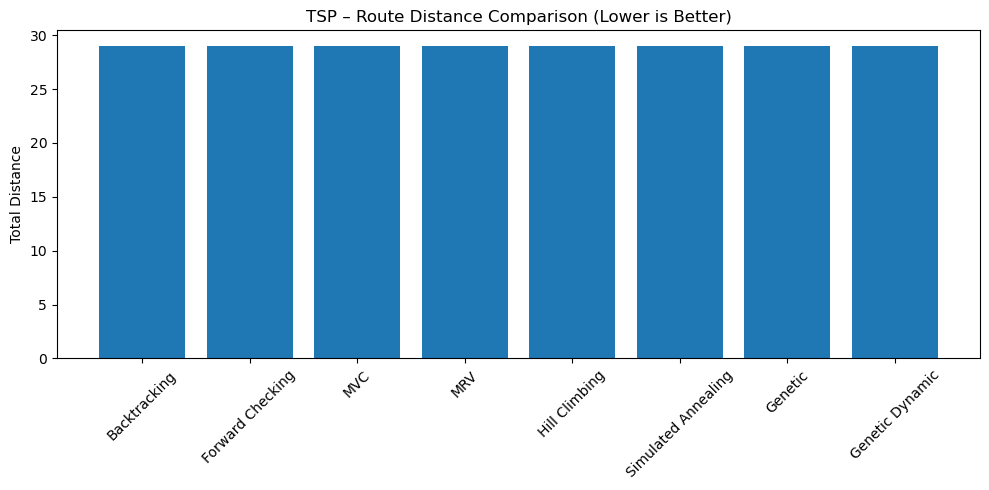

In [ ]:
import matplotlib.pyplot as plt

names = [r["name"] for r in results]
distances = [r["distance"] for r in results]

plt.figure(figsize=(10, 5))
plt.bar(names, distances)
plt.ylabel("Total Distance")
plt.title("TSP – Route Distance Comparison (Lower is Better)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


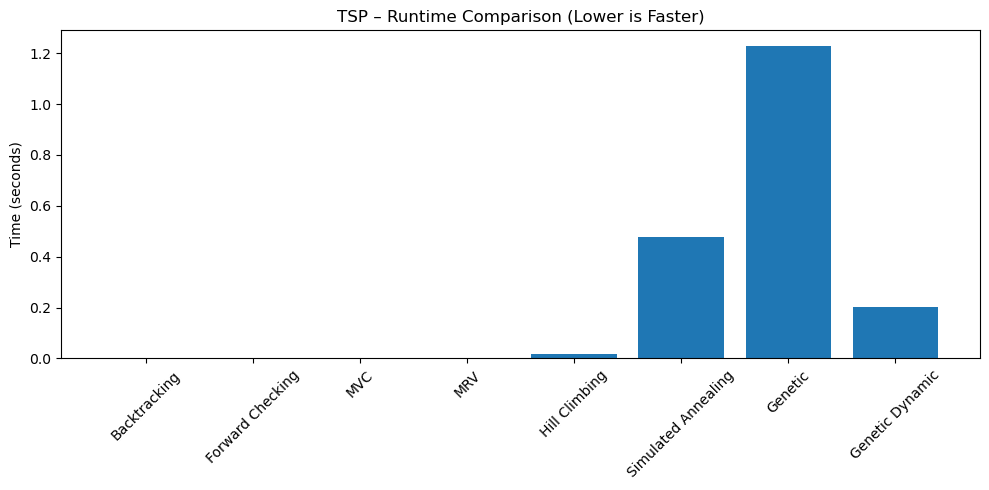

In [ ]:
times = [r["time"] for r in results]

plt.figure(figsize=(10, 5))
plt.bar(names, times)
plt.ylabel("Time (seconds)")
plt.title("TSP – Runtime Comparison (Lower is Faster)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


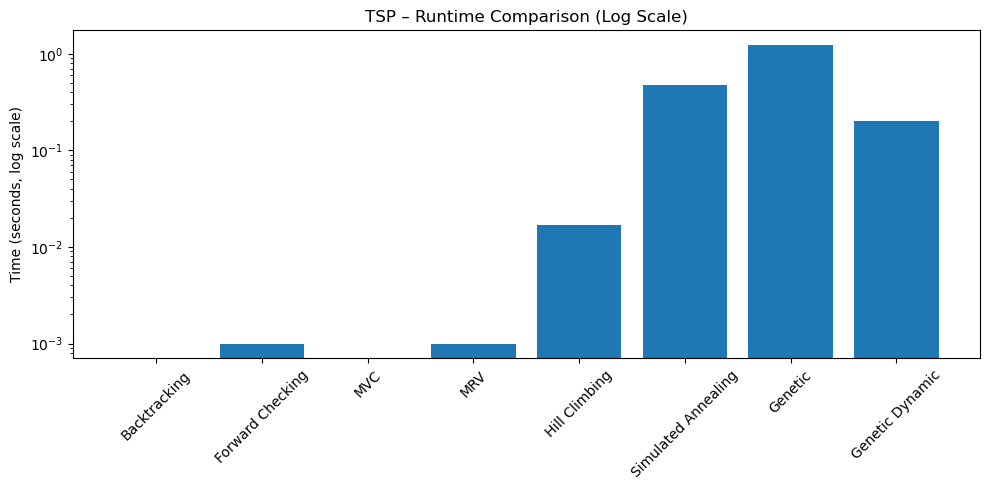

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(names, times)
plt.yscale("log")   
plt.ylabel("Time (seconds, log scale)")
plt.title("TSP – Runtime Comparison (Log Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
